# Graphons and GNNs for Physical Diffusion Prediction

This notebook presents multiple graphon generators, including a Perlin noise generator, and demonstrates how to sample graphs from them. For each graphon, the corresponding image and a few sampled graphs are shown. Finally, a simple Graph Neural Network (GNN) is built to predict a physical phenomenon: the diffusion of a substance on the network.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from typing import Callable, List, Tuple
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data, DataLoader
from torch_geometric.nn import GCNConv

try:
    from noise import pnoise2
except ImportError:
    raise ImportError('Please install the noise package: pip install noise')
 
np.random.seed(42)
torch.manual_seed(42)

## Graphon Generators

In [ ]:
from logic.graphon_generator import generate_constant_graphon, generate_min_graphon, generate_perlin_graphon, generate_piecewise_graphon

graphon_generators = [
    ("Constant Graphon (p=0.5)", generate_constant_graphon(0.5)),
    ("Piecewise Graphon (k=4)", generate_piecewise_graphon(4)),
    ("Min Graphon", generate_min_graphon()),
    ("Perlin Noise Graphon", generate_perlin_graphon())
]

## Graph Sampling and Visualization

### Display Graphons and Sampled Graphs

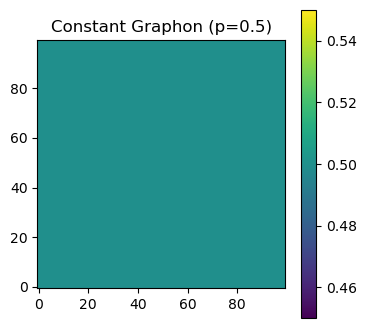

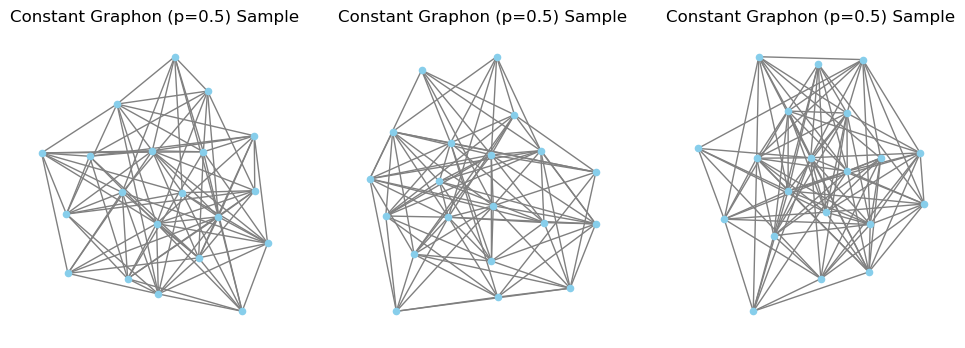

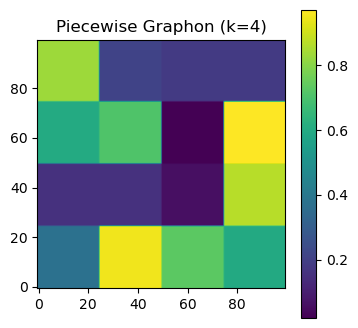

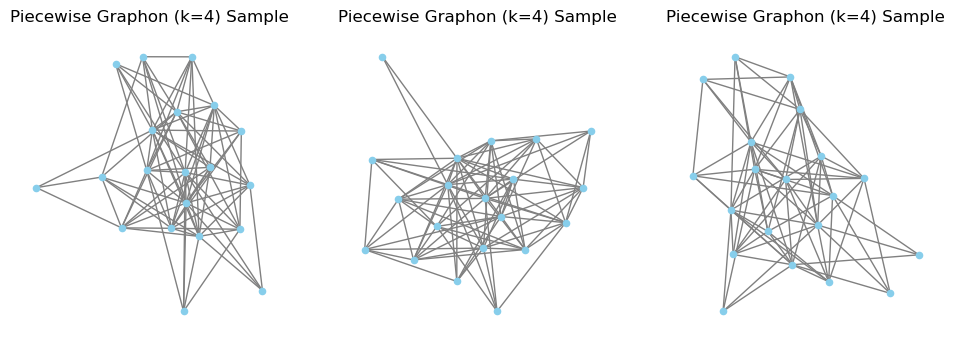

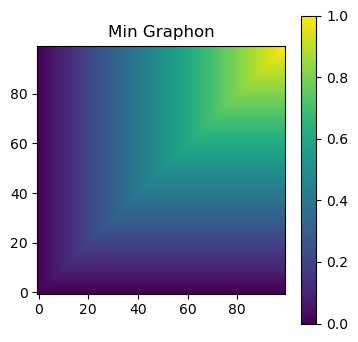

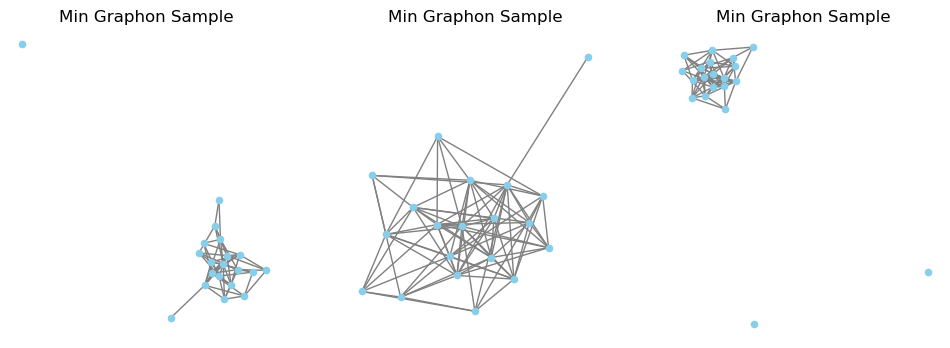

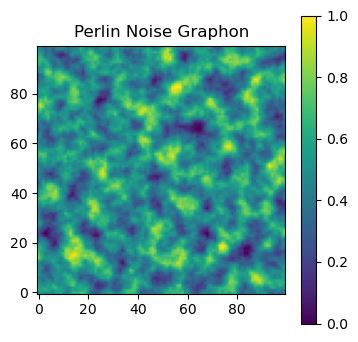

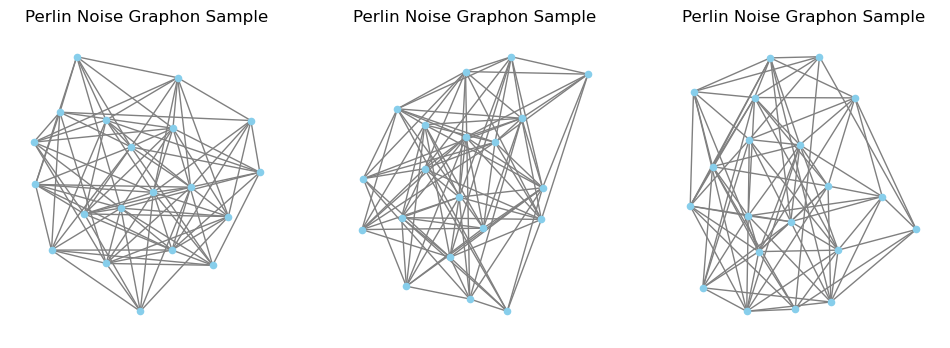

In [ ]:
from graphics.graphon_graphics import display_graphon, display_sampled_graphs
from logic.graphon_generator import interp_graphon


for name, W in graphon_generators:
    display_graphon(W, name)
    W_fn = interp_graphon(W)
    display_sampled_graphs(W_fn, f"{name} Sample", n=20)

## Physical processes over graphs

### Diffusion Process

In [ ]:
import matplotlib.animation as animation
from matplotlib import cm
from IPython.display import HTML

from logic.graphon_generator import sample_graph

def simulate_diffusion_step(A: np.ndarray, features: np.ndarray, diffusion_rate: float = 0.1) -> np.ndarray:
    d = np.array(A.sum(axis=1)).flatten()
    D = np.diag(d)
    L = D - A
    new_features = features - diffusion_rate * (L @ features)
    return new_features

def animate_diffusion(G: nx.Graph, initial_features: np.ndarray, steps: int = 20, diffusion_rate: float = 0.1) -> HTML:
    pos = nx.spring_layout(G, seed=42)
    A = nx.adjacency_matrix(G).todense()
    features = initial_features.copy()
    
    fig, ax = plt.subplots(figsize=(5, 5))
    cmap = cm.viridis
    nodes = nx.draw_networkx_nodes(G, pos, node_size=300,
                                   node_color=features.flatten(), cmap=cmap, ax=ax, vmin=0, vmax=1)
    nx.draw_networkx_edges(G, pos, ax=ax)
    ax.set_title("Diffusion Process Animation")
    ax.axis("off")
    
    def update(frame: int) -> None:
        nonlocal features
        features = simulate_diffusion_step(A, features, diffusion_rate)
        nodes.set_array(features.flatten())
        ax.set_title(f"Diffusion Step {frame+1}")
        return nodes,
    
    ani = animation.FuncAnimation(fig, update, frames=steps, interval=500, blit=False)
    plt.close(fig)
    return HTML(ani.to_jshtml())

# Demo: Animate diffusion on a sample graph
sample_G = sample_graph(interp_graphon(generate_min_graphon()), n=30)
initial_feat = np.random.rand(30, 1)
animate_diffusion(sample_G, initial_feat, steps=25)

## GNN for Physical Diffusion Prediction

We simulate a physical diffusion phenomenon on node features (e.g., representing substance concentration) by performing one diffusion step via the graph Laplacian. A simple GNN is built to predict the next state based on the current node features.

In [ ]:


class GCN(nn.Module):
    def __init__(self, in_channels: int, hidden_channels: int, out_channels: int):
        super().__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, out_channels)

    def forward(self, x: torch.Tensor, edge_index: torch.Tensor) -> torch.Tensor:
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = self.conv2(x, edge_index)
        return x

def simulate_diffusion(G: nx.Graph, features: np.ndarray) -> np.ndarray:
    A = nx.adjacency_matrix(G).todense()
    D = np.diag(np.array(A.sum(axis=1)).flatten())
    L = D - A
    new_features = features - 0.1 * L @ features
    return new_features

def graph_to_data(G: nx.Graph, features: np.ndarray, target: np.ndarray) -> Data:
    x = torch.tensor(features, dtype=torch.float32)
    edge_index = torch.tensor(list(G.edges()), dtype=torch.long).t().contiguous()
    if edge_index.numel() == 0:
        edge_index = torch.empty((2, 0), dtype=torch.long)
    data = Data(x=x, edge_index=edge_index, y=torch.tensor(target, dtype=torch.float32))
    return data

def generate_graph_dataset(W_fn: GraphonFunction, num_graphs: int, n_nodes: int) -> List[Data]:
    dataset: List[Data] = []
    for _ in range(num_graphs):
        G = sample_graph(W_fn, n_nodes)
        features = np.random.rand(n_nodes, 1)
        target = simulate_diffusion(G, features)
        data = graph_to_data(G, features, target)
        dataset.append(data)
    return dataset

def train_gnn(model: nn.Module, loader: torch.loader.DataLoader, epochs: int = 50) -> None:
    optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
    model.train()
    for _ in range(epochs):
        for batch in loader:
            optimizer.zero_grad()
            pred = model(batch.x, batch.edge_index)
            loss = F.mse_loss(pred, batch.y)
            loss.backward()
            optimizer.step()

def evaluate_gnn(model: nn.Module, loader: torch.loader.DataLoader) -> float:
    model.eval()
    loss_total = 0.0
    count = 0
    with torch.no_grad():
        for batch in loader:
            pred = model(batch.x, batch.edge_index)
            loss_total += F.mse_loss(pred, batch.y, reduction='sum').item()
            count += batch.num_nodes
    return loss_total / count

---

### Build and Train GNN on a Sample Graphon Dataset

Below we create a dataset from one of our graphon generators, instantiate a GNN model, train it, and evaluate its performance.

In [26]:
name, W = graphon_generators[2]
W_fn = interp_graphon(W)
dataset = generate_graph_dataset(W_fn, num_graphs=50, n_nodes=30)
loader = DataLoader(dataset, batch_size=10, shuffle=True)

model = GCN(in_channels=1, hidden_channels=16, out_channels=1)
train_gnn(model, loader, epochs=100)
loss = evaluate_gnn(model, loader)
print(f'Average MSE Loss: {loss:.4f}')

/home/astragaliton/anaconda3/lib/python3.11/site-packages/torch_geometric/deprecation.py:26: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  warnings.warn(out)


Average MSE Loss: 0.0250


## Conclusion

In this notebook, we generated various graphons, visualized them along with sample graphs, and set up a simple GNN to predict a diffusion process on the graphs. This framework can be extended to more complex prediction tasks on social or physical networks.